# Customer Churn Dataset - Exploratory Data Analysis

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Understanding Data

In [90]:
df = pd.read_csv('CustomerChurn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [91]:
df.shape

(7043, 21)

There are 7043 Rows and 21 Columns in the data set

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data Preprocessing

### Replacing Blanks as 0 and Converting Data Type for 'TotalCharges'

In [93]:
df['TotalCharges'] = df['TotalCharges'].replace(" ",0)
df['TotalCharges'] = df['TotalCharges'].astype("float") 

### Checking Null Values

In [94]:
df.isnull().sum().sum()

np.int64(0)

There are no null records in the data set.

In [95]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


This describes key attributes of the numeric columns in the data set

### Checking for Duplicated Data

In [96]:
df.duplicated().sum()

np.int64(0)

In [97]:
df.duplicated(subset='customerID').sum()

np.int64(0)

There are no Duplicated records in the data set.

### Transforming 'SeniorCitizen' Column

In [98]:
def convert(value):
     if value == 0:
          return 'No'
     else:
          return 'Yes'
     
df['SeniorCitizen'] = df['SeniorCitizen'].apply(convert)

This function transforms 0 -> No and 1 -> Yes

In [99]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Analysis 

### Counting number of Churns

Text(0, 0.5, 'Customers')

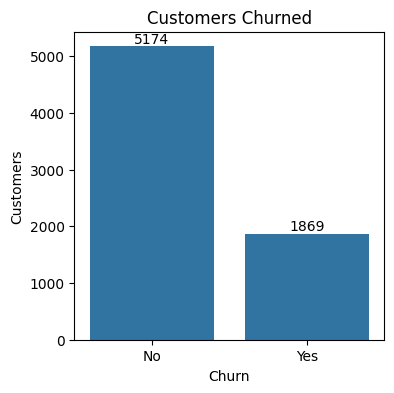

In [100]:
plt.figure(figsize=(4,4))
ax= sns.countplot(x= 'Churn', data = df)
ax.bar_label(ax.containers[0])
plt.title("Customers Churned")
plt.ylabel('Customers')

**In Percentage**

Text(0.5, 1.0, 'Churned Customers')

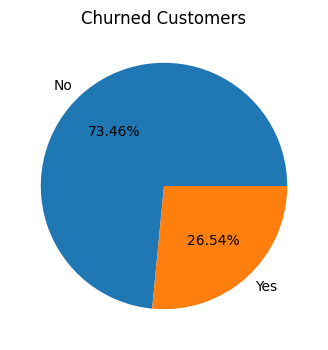

In [101]:
plt.figure(figsize=(4,4))
gb = df.groupby('Churn').agg({"Churn":"count"})
plt.pie(gb['Churn'], labels=gb.index, autopct= "%1.2f%%")
plt.title("Churned Customers")

From the Pie Chart, we can conclude that 26.54% customers churned out.

### Churn by Gender

Text(0, 0.5, 'Customers')

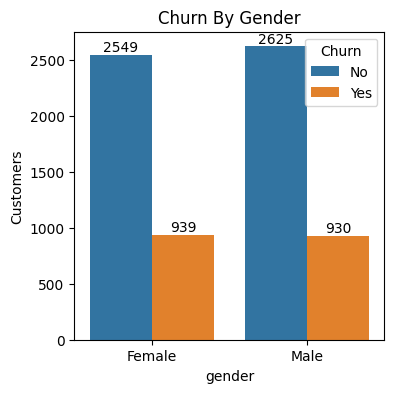

In [102]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="gender", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn By Gender")
plt.ylabel('Customers')

The above Graph concludes that the customer churn is gender independent.

### Churn by Senior Citizen

Text(0.5, 1.0, 'Churn By Senior Citizen')

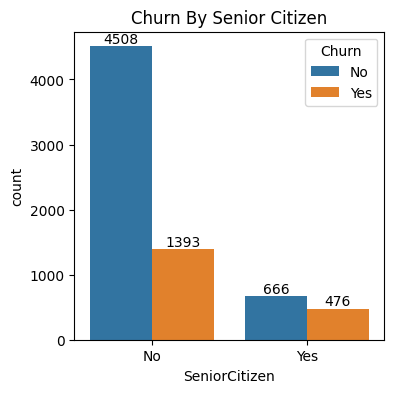

In [103]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="SeniorCitizen", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn By Senior Citizen")

The above graph clearly shows that Churn Rate is higher when the customer is a Senior Citizen.

### Churn by Tenure

Text(0.5, 0, 'Tenure')

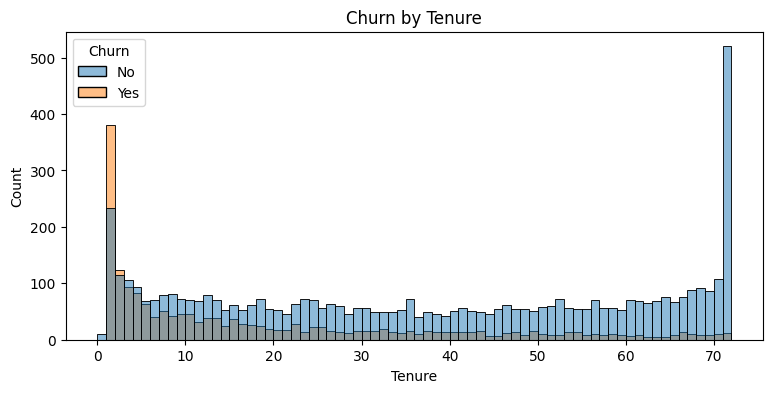

In [104]:
plt.figure(figsize=(9,4))
sns.histplot(x='tenure', data=df, hue='Churn', bins=72)
plt.title('Churn by Tenure')
plt.xlabel('Tenure')

The above visualization demonstrates that the Churn rate decreases as the tenure increases.

### Churn by Contract

Text(0, 0.5, 'Customers')

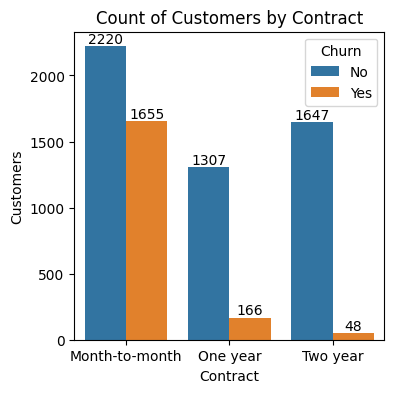

In [105]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x='Contract', data=df, hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Count of Customers by Contract')
plt.ylabel('Customers')

The above visulization shows the customers having a longer contract have a lower churn rate.

In [106]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

### Churn rate across different Services

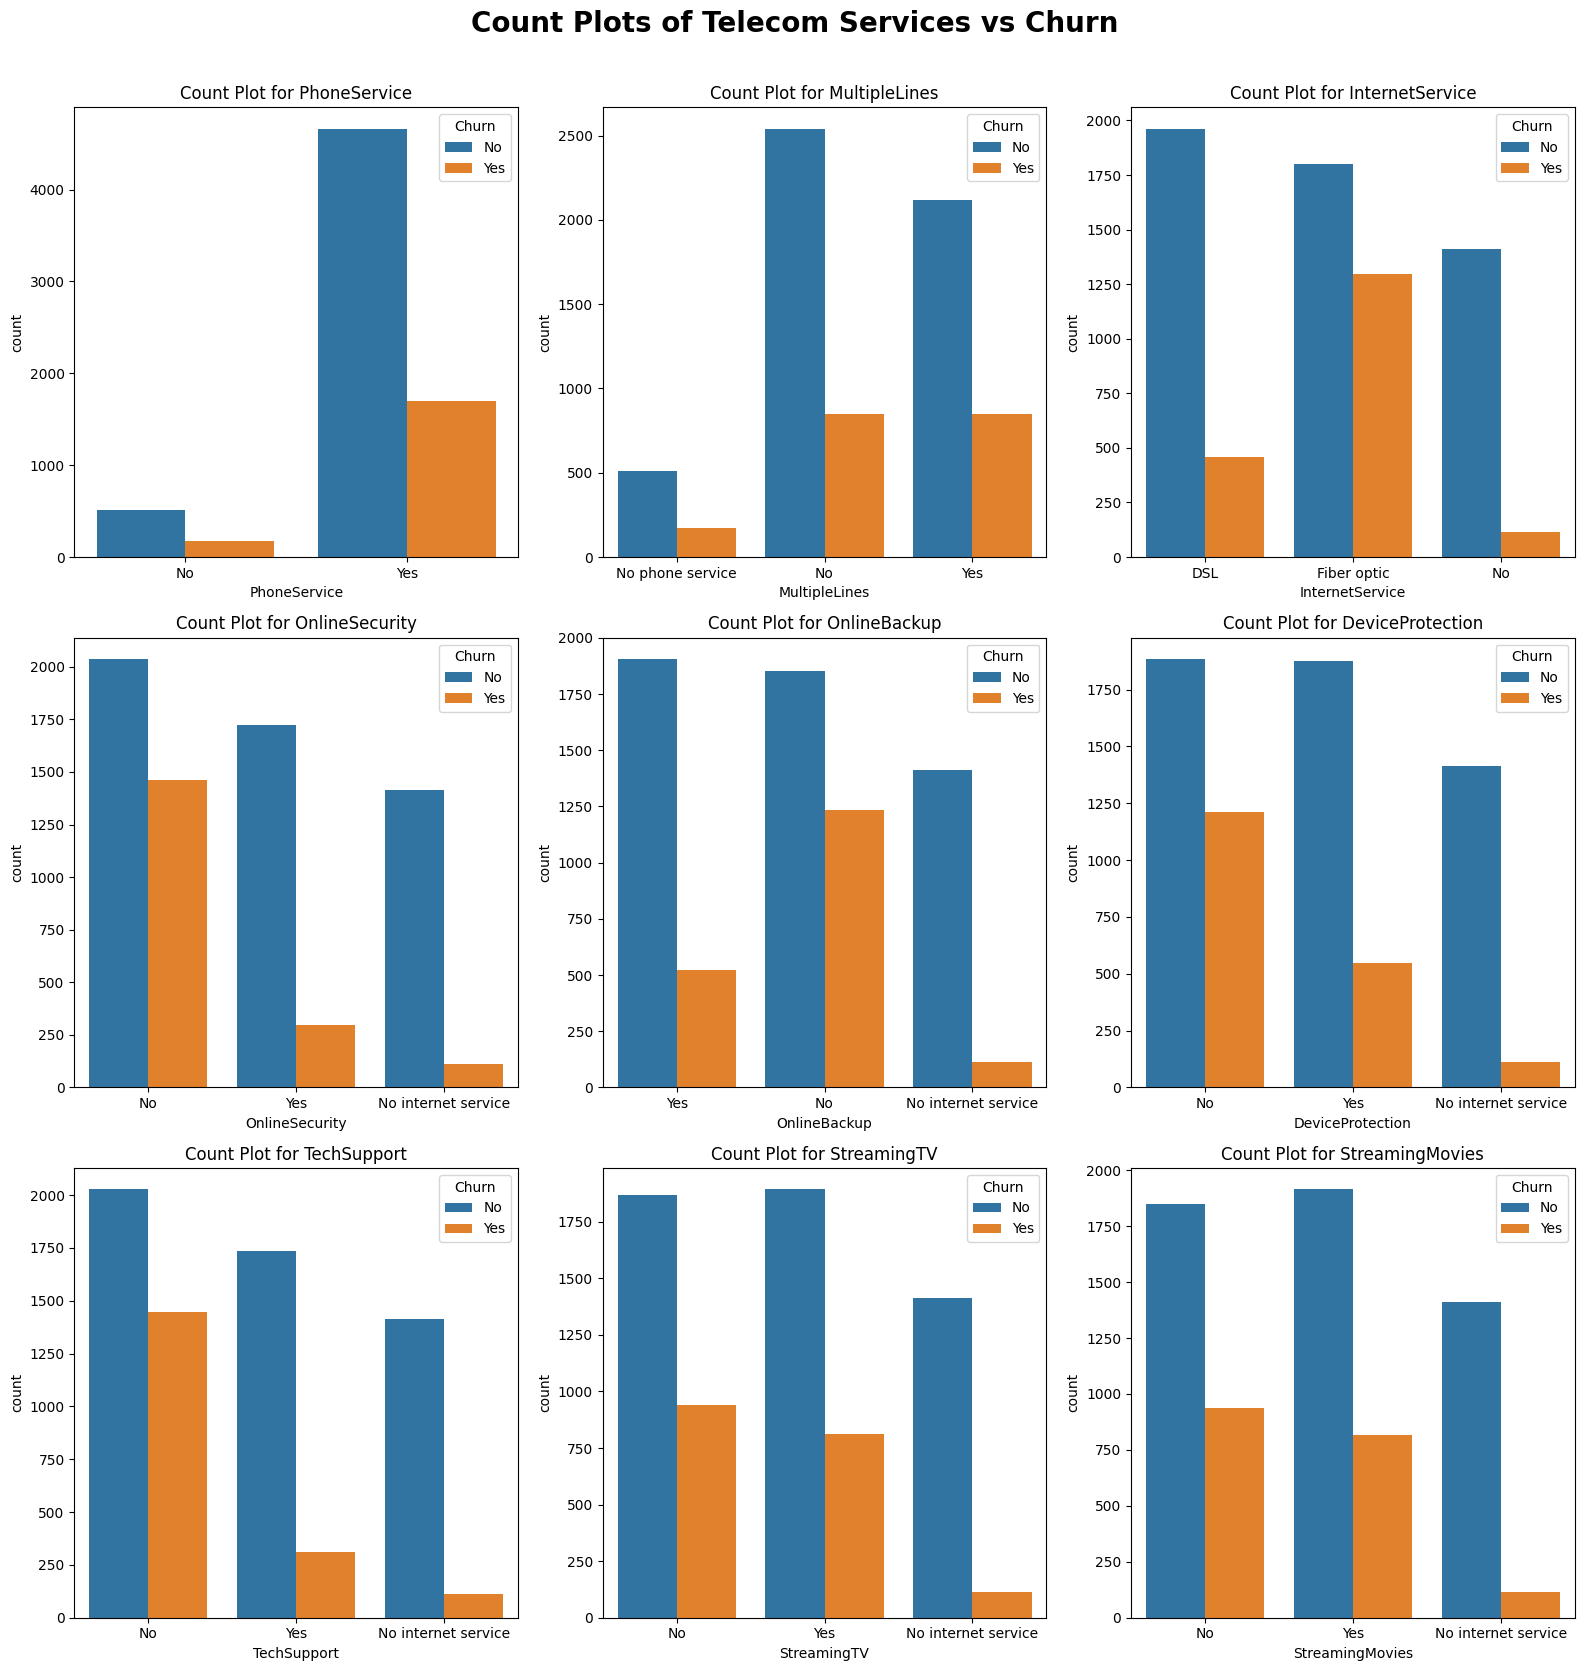

In [107]:
fig = plt.figure(figsize=(16,17))
fig.suptitle('Count Plots of Telecom Services vs Churn',fontsize=20,fontweight='bold')
plt.subplot(3,3,1)
sns.countplot(x='PhoneService', data=df, hue='Churn')
plt.title('Count Plot for PhoneService')
plt.subplot(3,3,2)
sns.countplot(x='MultipleLines', data=df, hue='Churn')
plt.title('Count Plot for MultipleLines')
plt.subplot(3,3,3)
sns.countplot(x='InternetService', data=df, hue='Churn')
plt.title('Count Plot for InternetService')
plt.subplot(3,3,4)
sns.countplot(x='OnlineSecurity', data=df, hue='Churn')
plt.title('Count Plot for OnlineSecurity')
plt.subplot(3,3,5)
sns.countplot(x='OnlineBackup', data=df, hue='Churn')
plt.title('Count Plot for OnlineBackup')
plt.subplot(3,3,6)
sns.countplot(x='DeviceProtection', data=df, hue='Churn')
plt.title('Count Plot for DeviceProtection')
plt.subplot(3,3,7)
sns.countplot(x='TechSupport', data=df, hue='Churn')
plt.title('Count Plot for TechSupport')
plt.subplot(3,3,8)
sns.countplot(x='StreamingTV', data=df, hue='Churn')
plt.title('Count Plot for StreamingTV')
plt.subplot(3,3,9)
sns.countplot(x='StreamingMovies', data=df, hue='Churn')
plt.title('Count Plot for StreamingMovies')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

The visualization shows that customer churn is strongly associated with internet and value-added services. Customers using Fiber Optic internet have the highest churn compared to DSL users and those without internet service. Similarly, customers who do not subscribe to Online Security, Online Backup, Device Protection, or Tech Support are more likely to churn, while those who use these services tend to remain with the company. In contrast, Phone Service and Multiple Lines appear to have a relatively minor impact on churn, as the distribution of churned and retained customers is similar across their categories. Overall, the results suggest that security, support, and protection services play an important role in improving customer retention.

### Churn rate based on Payment Method

Text(0.5, 1.0, 'Churn Rate by Payment Method')

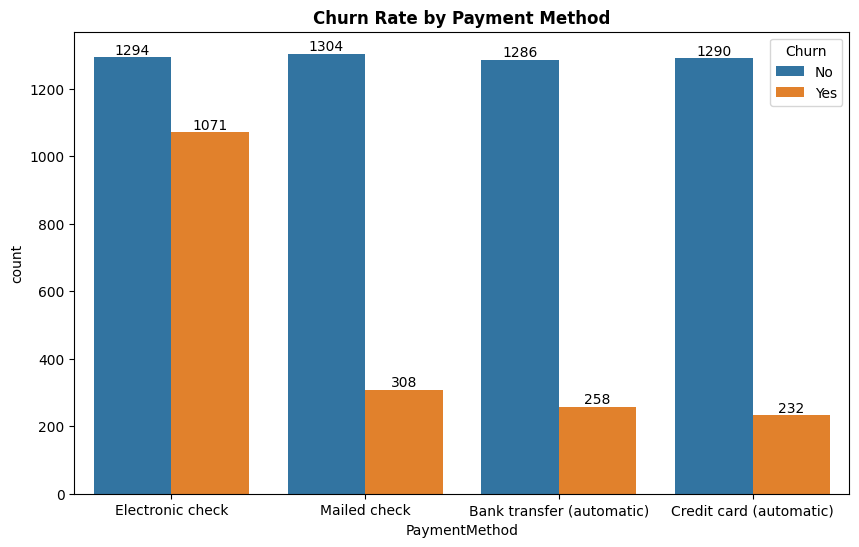

In [108]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x='PaymentMethod',data=df,hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn Rate by Payment Method", fontweight = 'bold')

The above graph shows that churn rate is lower where Payment Method is automatic, and higher where payment method is Electronic check.